# FlyGo: a researcher’s first experiment

Load a small 9×9 Go slice, construct the full fixed fly graph, inspect the
board-to-eye mapping and recurrent signals, then train every permitted parameter
and measure held-out policy KL. The defaults use the current Rust CPU rate-model
implementation, the spherical **current-board** adapter and all 2,129 motor
readouts. The recurrent graph contains 165,122 neurons and 15,270,273 edges.

This is an exploratory walkthrough. Its short run is not expected to reproduce
our best measured KL: **1.4903 mean** came from a separate K4, random-port,
smooth-rate study at 128,000 exposures. Here the goal is an understandable,
modifiable end-to-end experiment with biological input/output attachment.

Run cells in order. No TPU is initialized. The default fit has 64 updates / 2,048
labeled-position exposures, using 512 training and 256 validation positions.
Validation families are separate from training; final-test records are never read.


## Setup

From a checkout, with Python 3.12 and the Rust toolchain installed:

```bash
uv venv --python 3.12 .venv
uv pip install --python .venv/bin/python -e '.[notebook]'
.venv/bin/python -m ipykernel install --user --name flygo --display-name 'FlyGo (CPU)'
```

Select that kernel. On our research hosts, use a notebook environment that imports
the qualified `environments/2ba439e309df1e902b58/site-packages` package. The graph
and spherical adapter are existing immutable artifacts under `FLYGO_ROOT`.
See [the notebook README](README.md) for their paths and the Hugging Face format.


In [1]:
import os
# Set these before importing numerical libraries.
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')

from pathlib import Path, PurePosixPath
from dataclasses import asdict
from contextlib import nullcontext
import hashlib, json, time
import numpy as np
import matplotlib.pyplot as plt

from flygo.fly import FlyConfig, RustFly, load_graph
from flygo.attachments import load_attachment, runtime_hashes
from flygo.data.corpus import identity
from flygo.data.loader import Sampler
from flygo.go import Game, GameConfig
from flygo.schedule import Schedule
from flygo.storage import StorageBudget, GIB

ROOT = Path(os.environ.get('FLYGO_ROOT', '/dev/shm/flygo'))
DATA_SOURCE = os.environ.get('FLYGO_DATA_SOURCE', 'hub')  # 'local' uses the separate V0 release
HF_DATASET = os.environ.get('FLYGO_HF_DATASET', 'quintic/go9x9')
HF_REVISION = os.environ.get('FLYGO_HF_REVISION', '4f579b0a21c456f3bb568174d384056351124cd5')
HUB_MANIFEST = 'releases/v0-1m/manifest.json'
LOCAL_MANIFEST = ROOT / HUB_MANIFEST
GRAPH_PATH = ROOT / 'graphs/183e28b8d990ed5d3ffca091f0468d25dcca3dd1ccd98183e14615a09cda35b4'
ATTACHMENT_PATH = ROOT / 'ports/spherical-context-v1/attachment.npz'

SEED = 1
TRAIN_POSITIONS = int(os.environ.get('FLYGO_NOTEBOOK_TRAIN', '512'))
VAL_POSITIONS = int(os.environ.get('FLYGO_NOTEBOOK_VAL', '256'))
UPDATES = int(os.environ.get('FLYGO_NOTEBOOK_UPDATES', '64'))
BATCH_SIZE = 32
THREADS = min(24, len(os.sched_getaffinity(0)))
RUN = Path(os.environ.get('FLYGO_NOTEBOOK_RUN', str(ROOT / 'runs' / ('notebook-' + time.strftime('%Y%m%dT%H%M%SZ', time.gmtime()) + '-' + str(os.getpid())))))

# Keep the fleet's existing RAM buffers. On an independent workstation using a
# different artifact root, use its own resource policy.
resources = (StorageBudget(ROOT).reserve(files=64 << 20, heap=8*GIB, purpose='researcher notebook')
             if ROOT == Path('/dev/shm/flygo') else nullcontext())
resources.__enter__()
RUN.mkdir(parents=True, exist_ok=False)
os.environ.setdefault('HF_HOME', str(RUN / 'hf-cache'))
os.environ.setdefault('HF_HUB_DISABLE_XET', '1')
print({'runtime': RustFly.numerical_runtime, 'threads': THREADS,
       'data_source': HF_DATASET if DATA_SOURCE == 'hub' else str(LOCAL_MANIFEST), 'run': str(RUN)})


{'runtime': 'rust-fp32-circuit-f64-head-reductions-v3', 'threads': 4, 'data_source': 'quintic/go9x9', 'run': '/dev/shm/flygo/runs/research-notebook-hf-v1/experiment'}


## Load a small, reproducible Hugging Face slice

The default source is [quintic/go9x9](https://huggingface.co/datasets/quintic/go9x9),
pinned to the commit above. It contains 207,138 games / 19,598,695 pre-action
positions. The expert plays one of eight opponents of varying strength; the
same expert provides raw policy/value targets on **both players’ turns**.

The loader downloads four compact indices (about 28 MB), then uses HTTP byte
ranges to fetch only selected NPZ games from the tar shards. It verifies the
manifest, indices and each selected game by SHA-256. No complete shard is needed.
We take up to eight random positions per randomly selected game, using the
published opening-family split. This small teaching sample is not a balanced
opponent mixture or a uniform sample of all positions. Final-test labels are not read.

`raw_policy` is the teacher distribution, distinct from the played action and
search visits. `raw_value` favors the current player when positive, and is not
the final game outcome. The Rust Go engine replays the complete prefix, checks
stored stones and legal moves, and reconstructs four own/opponent board pairs,
turn, signed komi, passes and point legality: 12 channels in total.

For offline work on our existing V0 release, change `DATA_SOURCE` to `local`.
That is a separate one-million-position subset; results must record which source
was used. The graph and spherical adapter are the same prepared local artifacts.


In [2]:
def digest(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1 << 20), b''): h.update(block)
    return h.hexdigest()

def relative_path(name):
    path = PurePosixPath(name)
    if path.is_absolute() or '..' in path.parts:
        raise ValueError('Expected a repository-relative path')
    return str(path)

if DATA_SOURCE == 'hub':
    import gzip, io
    from huggingface_hub import HfApi, HfFileSystem, hf_hub_download
    hub_commit = HfApi().dataset_info(HF_DATASET, revision=HF_REVISION).sha
    hub_dir = RUN / 'hub'
    def hub_file(name):
        return Path(hf_hub_download(HF_DATASET, relative_path(name), repo_type='dataset',
                                   revision=hub_commit, local_dir=hub_dir))
    checksums = dict(line.split(maxsplit=1)[::-1]
                     for line in hub_file('SHA256SUMS').read_text().splitlines() if line.strip())
    checksums = {name.lstrip('*'): value for name, value in checksums.items()}
    manifest_path = hub_file('manifest.json')
    assert digest(manifest_path) == checksums['manifest.json']
    manifest = json.loads(manifest_path.read_text())
    dataset_id = manifest['release_id']
    records = []
    for item in manifest['indices']:
        path = hub_file(item['path'])
        assert path.stat().st_size == item['bytes'] and digest(path) == item['sha256']
        with gzip.open(path, 'rt') as stream:
            records.extend(json.loads(line) for line in stream)
    fs = HfFileSystem()
    shard_sizes = {item['path']: item['bytes'] for item in manifest['shards']}
    def game_file(record):
        # Each index gives the byte offset of a complete compressed NPZ payload
        # inside an uncompressed tar. Seek/read uses HTTP Range, without untarring.
        shard = relative_path(record['shard'])
        offset, size = record['offset'], record['bytes']
        assert 0 <= offset < offset+size <= shard_sizes[shard]
        path = hub_dir / 'selected-games' / (record['sha256'] + '.npz')
        if not path.exists():
            remote = f'datasets/{HF_DATASET}@{hub_commit}/{shard}'
            with fs.open(remote, 'rb', block_size=1, cache_type='none') as stream:
                stream.seek(offset)
                payload = stream.read(size)
            assert len(payload) == size and hashlib.sha256(payload).hexdigest() == record['sha256']
            path.parent.mkdir(parents=True, exist_ok=True)
            path.write_bytes(payload)
        return path
elif DATA_SOURCE == 'local':
    hub_commit = None
    manifest_path = LOCAL_MANIFEST
    manifest = json.loads(manifest_path.read_text())
    dataset_id = manifest['dataset_id']
    assert identity({k:v for k,v in manifest.items() if k != 'dataset_id'}) == dataset_id
    records = manifest['records']
    def game_file(record): return ROOT / relative_path(record['path'])
else:
    raise ValueError("DATA_SOURCE must be 'hub' or 'local'")

assert min(TRAIN_POSITIONS, VAL_POSITIONS, BATCH_SIZE) > 0 and UPDATES >= 0

def load_slice(split, limit, seed):
    candidates = [r for r in records if r['split'] == split]
    order = np.random.default_rng(seed).permutation(len(candidates))
    position_rng = np.random.default_rng(seed+1)
    features, legal, policy, values, row_ids, families = [], [], [], [], [], []
    for index in order:
        record = candidates[int(index)]; path = game_file(record)
        assert digest(path) == record['sha256']
        with np.load(path, allow_pickle=False) as saved:
            metadata = json.loads(saved['metadata'].tobytes())
            assert metadata['opening_family'] == record['opening_family']
            assert metadata['game_id'] == record['game_id']
            game = Game(GameConfig(size=9, komi=7.5, history=4))
            count = min(8, limit-len(features), len(saved['actions']))
            selected = set(map(int, position_rng.choice(len(saved['actions']), count, replace=False)))
            for ply, action in enumerate(saved['actions']):
                # Reconstruct the complete causal prefix even for late samples.
                if ply in selected:
                    x = game.features().copy()
                    mask = np.zeros(82, bool); mask[game.legal()] = True
                    np.testing.assert_array_equal(mask, saved['legal'][ply])
                    np.testing.assert_array_equal(game.state().stones, saved['stones'][ply])
                    features.append(x); legal.append(mask)
                    policy.append(saved['raw_policy'][ply].copy()); values.append(saved['raw_value'][ply])
                    row_ids.append(str(record['game_id']) + ':' + str(ply))
                    families.append(record['opening_family'])
                if ply == max(selected): break
                game.play(game.state().to_play, int(action))
        if len(features) == limit: break
    if len(features) != limit: raise ValueError('The split is smaller than the requested slice')
    result = dict(features=np.asarray(features, np.float32), legal=np.asarray(legal, bool),
                  raw_policy=np.asarray(policy, np.float32), raw_value=np.asarray(values, np.float32))
    assert np.isfinite(result['raw_policy']).all() and np.isfinite(result['raw_value']).all()
    assert not np.any(result['raw_policy'][~result['legal']]) and (result['raw_policy'] >= 0).all()
    np.testing.assert_allclose(result['raw_policy'].sum(axis=1), 1, atol=1e-5, rtol=0)
    return result, row_ids, families

train, train_ids, train_families = load_slice('train', TRAIN_POSITIONS, 918719)
validation, val_ids, val_families = load_slice('validation', VAL_POSITIONS, 918721)
assert set(train_families).isdisjoint(val_families)
print({'dataset_id': dataset_id, 'hub_commit': hub_commit,
       'train_positions': len(train_ids), 'train_families': len(set(train_families)),
       'validation_positions': len(val_ids), 'validation_families': len(set(val_families))})
print({name: (array.shape, str(array.dtype)) for name, array in train.items()})


/dev/shm/flygo/environments/notebook-cpu-20260915-v1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'dataset_id': '6a26ffa743f3c7be95d783102f6b3596e0ce69893c5a8e28dcca154dc54f05f4', 'hub_commit': '4f579b0a21c456f3bb568174d384056351124cd5', 'train_positions': 512, 'train_families': 55, 'validation_positions': 256, 'validation_families': 12}
{'features': ((512, 9, 9, 12), 'float32'), 'legal': ((512, 82), 'bool'), 'raw_policy': ((512, 82), 'float32'), 'raw_value': ((512,), 'float32')}


## Construct the full network

For each internal pass,

$$h_{t+1}=(1-\alpha)\odot h_t+\alpha\odot[W\,r(h_t)+b+I(x)],\qquad
\alpha=0.01+0.98\,\sigma(\lambda).$$

The default rate is $r(h)=\max(h,0)$. Strength magnitudes are
$\mathrm{softplus}(\theta_e)$, with a fixed approximate neurotransmitter sign for
each source neuron. Initial magnitudes come from incoming-normalized
$\log(1+\text{synapse count})$. These are modeling priors, not measured conductances.
Type biases/leaks, input gains, readout gains and both heads are also learnable.

The topology stays fixed. Rust streams the sparse computations without an
edge-by-batch tensor. This notebook resets $h_0=0.01$ for each position; internal
passes do not carry memory across successive Go moves. Their time unit is not
calibrated biological time.


In [3]:
graph = load_graph(GRAPH_PATH)  # validates the canonical arrays against their hashes
adapter, ports, attachment = load_attachment(ATTACHMENT_PATH, graph_id=graph['manifest']['graph_id'])
config = FlyConfig(steps=8, features=adapter.features, groups=attachment['groups'],
                   actions=82, threads=THREADS, seed=SEED, rate_softness=0.0)
model = RustFly(graph, config, ports=ports)  # dense learned policy/value projections
MODE = 'current'  # alternatives: 'history' and 'neutral', each a separate experiment

def encode(x): return adapter.encode(x, MODE)
print(asdict(config))
print({'neurons': len(graph['type_id']), 'edges': len(graph['src']),
       'visual_features': len(adapter.renderer.index), 'context_features': 84,
       'motor_readouts': config.groups, 'stored_parameters': sum(a.size for a in model.parameters().values())})


{'steps': 8, 'features': 3574, 'groups': 2129, 'actions': 82, 'threads': 4, 'seed': 1, 'rate_softness': 0.0, 'readout_mean_scale': 1.0}
{'neurons': 165122, 'edges': 15270273, 'visual_features': 3490, 'context_features': 84, 'motor_readouts': 2129, 'stored_parameters': 15639263}


## Inspect weights and neuron metadata

`edge[e]` indexes a permitted directed edge, with destination/source order fixed
by the graph. `type_id` ties bias and leak parameters across neurons of the same
annotated type. A scalar stored in `edge` is an unconstrained magnitude parameter;
inspect the transformed signed weight when interpreting transmission.


edge                (15270273,)  mean=-5.1045  std= 1.1
leak                   (11752,)  mean= 0  std= 0
bias                   (11752,)  mean= 0.02  std= 3.7253e-09
input_gain              (3574,)  mean= 0.2  std= 2.9802e-08
readout_gain          (165122,)  mean= 1  std= 0
policy_weight         (174578,)  mean=-4.7671e-05  std= 0.019971
policy_bias               (82,)  mean= 0  std= 0
value_weight            (2129,)  mean= 9.5673e-05  std= 0.019465
value_bias                 (1,)  mean= 0  std= 0
{'node_index': 1053, 'body_id': 11139, 'type': 'R1-R6', 'transmitter': 'histamine', 'in_degree': 1, 'out_degree': 6}
{'node_index': 5045, 'body_id': 15479, 'type': 'R8p', 'transmitter': 'histamine', 'in_degree': 3, 'out_degree': 16}
{'node_index': 5173, 'body_id': 15625, 'type': 'R8y', 'transmitter': 'histamine', 'in_degree': 3, 'out_degree': 20}
{'node_index': 0, 'body_id': 10001, 'type': 'DNp01', 'transmitter': 'acetylcholine', 'in_degree': 560, 'out_degree': 184}
{'node_index': 6, 'body_id

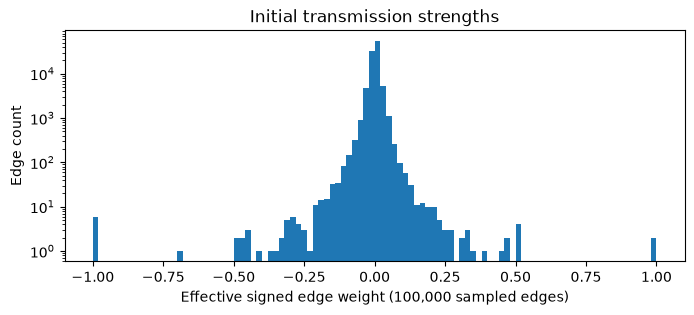

In [4]:
parameters = model.parameters()
for name, array in parameters.items():
    print(f'{name:16s} {str(array.shape):>14s}  mean={array.mean(): .5g}  std={array.std(): .5g}')

body_id = np.load(GRAPH_PATH / 'body_id.npy', mmap_mode='r', allow_pickle=False)
type_names = np.load(GRAPH_PATH / 'type_names.npy', allow_pickle=False)
nt = np.load(GRAPH_PATH / 'consensus_nt.npy', allow_pickle=False)
motors = np.flatnonzero(ports['output_group'] >= 0)
motors = motors[np.argsort(ports['output_group'][motors])]
visual_nodes = np.flatnonzero((ports['input_index'] >= 0) & (ports['input_index'] < len(adapter.renderer.index)))
out_degree = np.bincount(graph['src'], minlength=len(body_id))
for node in np.r_[visual_nodes[:3], motors[:3]]:
    print({'node_index': int(node), 'body_id': int(body_id[node]),
           'type': str(type_names[graph['type_id'][node]]), 'transmitter': str(nt[node]),
           'in_degree': int(graph['indptr'][node+1]-graph['indptr'][node]), 'out_degree': int(out_degree[node])})

edge_ids = np.random.default_rng(SEED).choice(len(graph['src']), 100000, replace=False)
weights = graph['sign'][graph['src'][edge_ids]] * np.logaddexp(0, parameters['edge'][edge_ids])
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(weights, bins=100, log=True)
ax.set(xlabel='Effective signed edge weight (100,000 sampled edges)', ylabel='Edge count', title='Initial transmission strengths')
plt.show()
del parameters


## See the board on both eyes

The map uses inferred visual columns and an **engineered local spherical chart**.
The angles are not measured optical axes, and receptor density is not a claim
about fly acuity. Current mode repeats the current board in the existing montage
on each eye. History mode instead uses the registered alternating history lags.
All receptor classes at a column see the same grayscale luminance here.


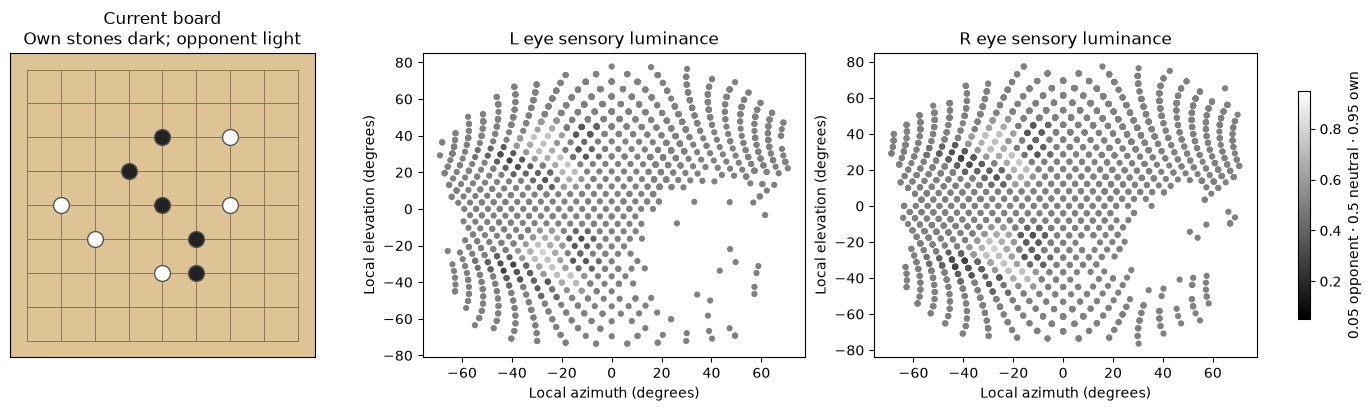

[{'eye': 'L', 'lag': 0, 'sensors': 391, 'illuminated_sensors': 329, 'covered_board_points': 81, 'point_mass_min': 1.8326732367277145, 'point_mass_max': 6.802724599838257}, {'eye': 'L', 'lag': 2, 'sensors': 937, 'illuminated_sensors': 449, 'covered_board_points': 81, 'point_mass_min': 1.5626357793807983, 'point_mass_max': 22.124244317412376}, {'eye': 'R', 'lag': 1, 'sensors': 802, 'illuminated_sensors': 607, 'covered_board_points': 81, 'point_mass_min': 2.649323970079422, 'point_mass_max': 16.07526382803917}, {'eye': 'R', 'lag': 3, 'sensors': 1360, 'illuminated_sensors': 692, 'covered_board_points': 81, 'point_mass_min': 3.1252715587615967, 'point_mass_max': 27.904699087142944}]


In [5]:
example = train['features'][min(24, len(train['features'])-1):min(24, len(train['features'])-1)+1]
rendered = encode(example)[0, :len(adapter.renderer.index)]
unit = adapter.renderer.unit
azimuth = np.degrees(np.arctan2(unit[:, 1], unit[:, 0]))
elevation = np.degrees(np.arcsin(unit[:, 2]))

def draw_board(ax, features):
    ax.set_facecolor('#dec394')
    for line in range(9):
        ax.plot([0,8], [line,line], color='#8d7652', lw=.7)
        ax.plot([line,line], [0,8], color='#8d7652', lw=.7)
    for channel, color in [(0,'#222222'), (1,'#ffffff')]:
        row, col = np.nonzero(features[..., channel] > .5)
        ax.scatter(col, row, c=color, edgecolors='#555555', s=130, zorder=3)
    ax.set(xlim=(-.5,8.5), ylim=(8.5,-.5), aspect='equal', xticks=[], yticks=[])

fig, axes = plt.subplots(1, 3, figsize=(14,4), layout='constrained')
draw_board(axes[0], example[0]); axes[0].set_title('Current board\nOwn stones dark; opponent light')
for ax, eye in zip(axes[1:], ['L','R']):
    selected = adapter.renderer.side == eye
    artist = ax.scatter(azimuth[selected], elevation[selected], c=rendered[selected], vmin=.05, vmax=.95, cmap='gray', s=12)
    ax.set(xlabel='Local azimuth (degrees)', ylabel='Local elevation (degrees)', title=eye+' eye sensory luminance')
fig.colorbar(artist, ax=axes[1:], label='0.05 opponent · 0.5 neutral · 0.95 own', shrink=.75)
plt.show()
print(adapter.renderer.audit())


## Trace recurrent signal propagation

The second forward replaces only the visual image with neutral luminance and
keeps context fixed. Its difference from the board-driven trace reveals where
this image affects activity. The heatmap selects the strongest responding motors
for this one example; it does not establish permanent biological action groups.


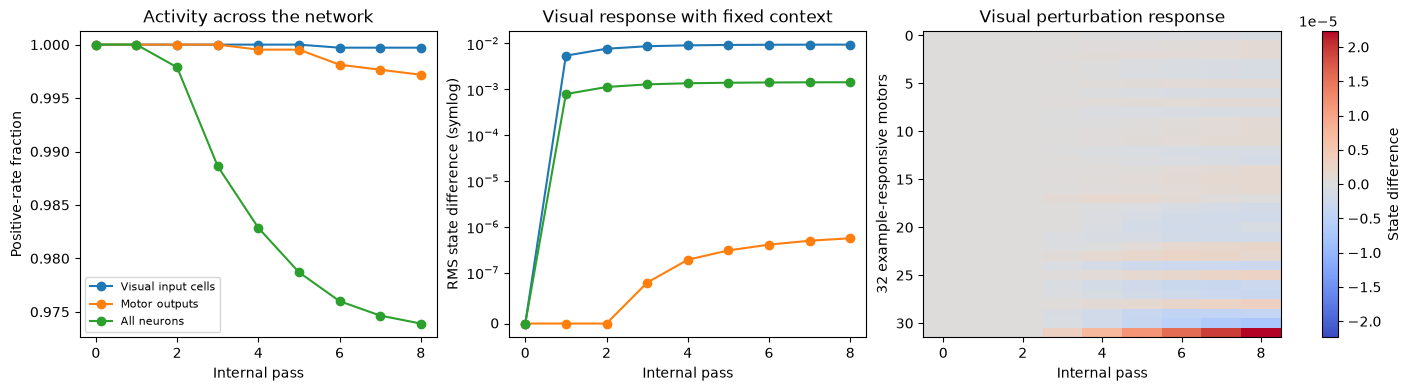

In [6]:
prediction = model.infer(encode(example), trace=True)
neutral = model.infer(adapter.encode(example, 'neutral'), trace=True)
states = np.asarray(prediction['states'])[:, :, 0]
delta = states - np.asarray(neutral['states'])[:, :, 0]
groups = {'Visual input cells': visual_nodes, 'Motor outputs': motors,
          'All neurons': np.arange(len(graph['type_id']))}
fig, axes = plt.subplots(1,3,figsize=(14,3.8), layout='constrained')
for name, indices in groups.items():
    axes[0].plot(np.mean(states[:,indices] > 0, axis=1), marker='o', label=name)
    axes[1].plot(np.sqrt(np.mean(delta[:,indices].astype(np.float64)**2,axis=1)), marker='o', label=name)
axes[0].set(xlabel='Internal pass', ylabel='Positive-rate fraction', title='Activity across the network')
axes[1].set(xlabel='Internal pass', ylabel='RMS state difference (symlog)', title='Visual response with fixed context')
axes[1].set_yscale('symlog', linthresh=1e-7)
axes[0].legend(fontsize=8)
selected_motors = motors[np.argsort(np.max(np.abs(delta[:,motors]),axis=0))[-32:]]
magnitude = max(float(np.abs(delta[:,selected_motors]).max()), 1e-12)
artist = axes[2].imshow(delta[:,selected_motors].T, aspect='auto', cmap='coolwarm',
                        vmin=-magnitude, vmax=magnitude)
axes[2].set(xlabel='Internal pass', ylabel='32 example-responsive motors', title='Visual perturbation response')
fig.colorbar(artist, ax=axes[2], label='State difference')
plt.show()
del neutral, prediction, states, delta


## Define validation metrics explicitly

For teacher distribution $q$ and legal student distribution $p$,
$D_{KL}(q\Vert p)=\sum_a q_a(\log q_a-\log p_a)$, in nats. Cross entropy
includes the teacher’s entropy, so it is not numerically the same as KL.
We average per-position KL and value squared error over the held-out slice.
Confidence and entropy are diagnostics, not substitutes for matching the teacher.


In [7]:
def evaluate(data):
    totals = dict(policy_kl=0., value_mse=0., policy_entropy=0., top_probability=0., teacher_top1=0.)
    count = len(data['features'])
    for start in range(0,count,BATCH_SIZE):
        stop = min(start+BATCH_SIZE,count)
        out = model.infer(encode(data['features'][start:stop]))
        legal = data['legal'][start:stop]
        q = data['raw_policy'][start:stop].astype(np.float64)
        z = np.where(legal,out['logits'].astype(np.float64),-np.inf)
        z -= z.max(axis=1,keepdims=True)
        logp = np.where(legal,z-np.log(np.exp(z).sum(axis=1,keepdims=True)),-1e30)
        p = np.exp(logp)
        totals['policy_kl'] += float(np.sum(q*(np.log(np.maximum(q,1e-300))-logp)))
        totals['value_mse'] += float(np.square(out['value'].astype(np.float64)-data['raw_value'][start:stop]).sum())
        totals['policy_entropy'] += float(-(p*logp).sum())
        totals['top_probability'] += float(p.max(axis=1).sum())
        totals['teacher_top1'] += float((p.argmax(axis=1)==q.argmax(axis=1)).sum())
    return {key:value/count for key,value in totals.items()}

initial_validation = evaluate(validation)
print('Initial held-out slice:', initial_validation)


Initial held-out slice: {'policy_kl': 2.0380651243488606, 'value_mse': 0.8899373106043366, 'policy_entropy': 3.633108504304945, 'top_probability': 0.03403918570623217, 'teacher_top1': 0.05078125}


## Fit the entire fixed-topology model

Each call below backpropagates through all eight recurrent passes. Every edge
magnitude and the permitted local/head parameters can learn. The sampler applies
the same D4 transform to every historical board and the policy/legal targets.
We use the current spherical-study schedule: peak rate .03, 100-update warmup,
epsilon 1e-6 and a .01 multiplier for type biases. These are editable research
settings; keep a fresh run and record your changes rather than overwriting a
comparison’s checkpoint.


In [8]:
sampler = Sampler(train, {'train':np.arange(len(train_ids),dtype=np.int64)}, seed=SEED)
schedule = Schedule(peak=.03, warmup_steps=100)
curve = [dict(step=0, exposures=0, validation=initial_validation)]
started = time.time()
for step in range(1, UPDATES+1):
    x, legal, policy, value = sampler.batch(BATCH_SIZE)
    metrics = model.train_step(encode(x), legal, policy, value,
        rate=schedule.rate(step), clip=1., rate_scales={'bias':.01}, epsilon=1e-6)
    if step % 16 == 0 or step == UPDATES:
        heldout = evaluate(validation)
        curve.append(dict(step=step, exposures=step*BATCH_SIZE,
                          training_batch=metrics, validation=heldout))
        print(f"step={step:4d} exposures={step*BATCH_SIZE:6d} "
              f"KL={heldout['policy_kl']:.6f} value_MSE={heldout['value_mse']:.6f} "
              f"elapsed={time.time()-started:.1f}s")


step=  16 exposures=   512 KL=1.991948 value_MSE=0.918194 elapsed=73.7s


step=  32 exposures=  1024 KL=1.960121 value_MSE=0.945944 elapsed=149.1s


step=  48 exposures=  1536 KL=1.970215 value_MSE=0.890330 elapsed=228.8s


step=  64 exposures=  2048 KL=1.901372 value_MSE=0.901081 elapsed=300.5s


Final held-out-slice KL: 1.9013720086098855
Final held-out-slice value MSE: 0.9010808110544362
Positions: 256 | independent opening families: 12


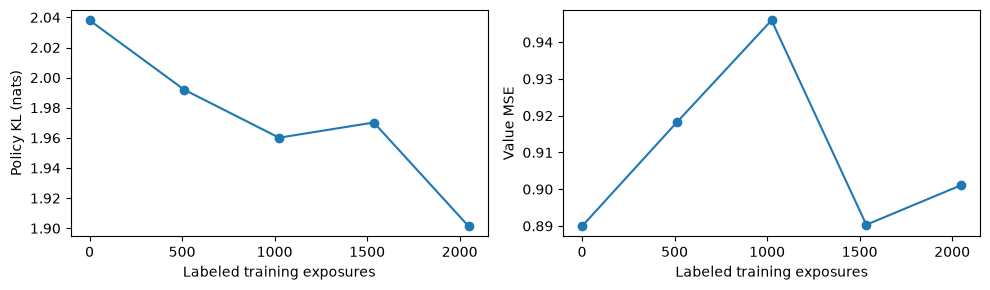

Experiment record: /dev/shm/flygo/runs/research-notebook-hf-v1/experiment/result.json


In [9]:
final_validation = evaluate(validation)
print('Final held-out-slice KL:', final_validation['policy_kl'])
print('Final held-out-slice value MSE:', final_validation['value_mse'])
print('Positions:', len(val_ids), '| independent opening families:', len(set(val_families)))

fig, axes = plt.subplots(1,2,figsize=(10,3))
for ax,metric,title in zip(axes,['policy_kl','value_mse'],['Policy KL (nats)','Value MSE']):
    ax.plot([r['exposures'] for r in curve],[r['validation'][metric] for r in curve],marker='o')
    ax.set(xlabel='Labeled training exposures', ylabel=title)
fig.tight_layout(); plt.show()

summary = dict(dataset_id=dataset_id,data_source=DATA_SOURCE,
               hf_dataset=HF_DATASET if DATA_SOURCE == 'hub' else None,hf_revision=hub_commit,
               manifest_sha256=digest(manifest_path),
               graph_id=graph['manifest']['graph_id'],attachment_sha256=attachment['sha256'],
               model=asdict(config),input_mode=MODE,runtime=runtime_hashes(),
               train_positions=len(train_ids),validation_positions=len(val_ids),
               train_families=len(set(train_families)),validation_families=len(set(val_families)),
               train_ids_sha256=hashlib.sha256(json.dumps(train_ids).encode()).hexdigest(),
               val_ids_sha256=hashlib.sha256(json.dumps(val_ids).encode()).hexdigest(),
               schedule=schedule.contract(),epsilon=1e-6,rate_scales={'bias':.01},
               updates=UPDATES,exposures=UPDATES*BATCH_SIZE,curve=curve,final_validation=final_validation,
               scope='Small exploratory slice; not full validation, final test, or a CNN comparison.')
(RUN/'result.json').write_text(json.dumps(summary,indent=2)+'\n')
print('Experiment record:', RUN/'result.json')


## Inspect the learned policy and choose the next experiment

Try one change at a time: more updates; rate or type-bias scaling; internal
passes; history/current inputs; a different permitted readout; or the optional
smooth rate. Changing a setting creates a new experiment. Read
[the readout study](../docs/readout-roles-study.md) and
[the motor-learnability plan](../configs/motor-learnability-v1.json) before
interpreting a more confident output as a better representation.

To compare configurations, instantiate a fresh model, reuse the same split and
sampling seed, count training exposures and prediction work, and keep every
declared endpoint. The small validation slice here is for iteration; use the
full registered validation and fresh games for scientific conclusions.


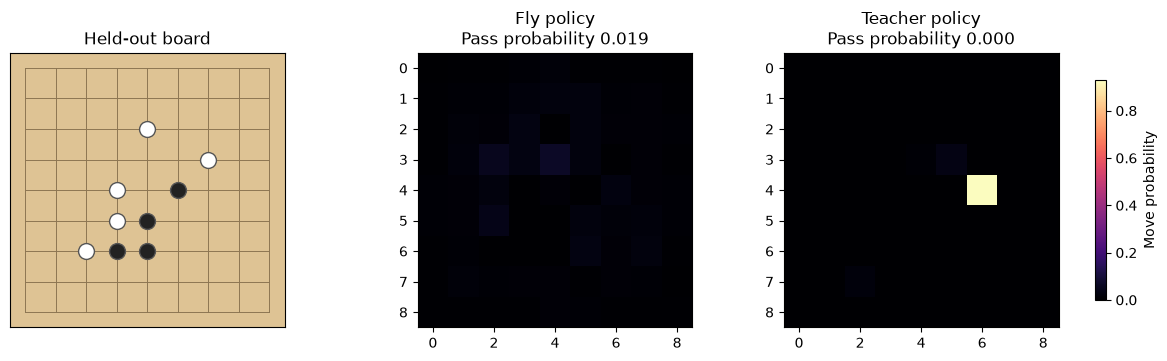

False

In [10]:
chosen = validation['features'][min(24,len(val_ids)-1):min(24,len(val_ids)-1)+1]
out = model.infer(encode(chosen)); legal = validation['legal'][min(24,len(val_ids)-1)]
z = np.where(legal,out['logits'][0].astype(np.float64),-np.inf)
p = np.exp(z-z.max()); p /= p.sum()
teacher = validation['raw_policy'][min(24,len(val_ids)-1)]
fig, axes = plt.subplots(1,3,figsize=(12,3.5), layout='constrained')
draw_board(axes[0],chosen[0]); axes[0].set_title('Held-out board')
limit = max(float(p[:81].max()),float(teacher[:81].max()))
for ax,probability,label in zip(axes[1:],[p,teacher],['Fly policy','Teacher policy']):
    artist=ax.imshow(probability[:81].reshape(9,9),vmin=0,vmax=limit,cmap='magma')
    ax.set_title(label+f'\nPass probability {probability[81]:.3f}')
fig.colorbar(artist,ax=axes[1:],label='Move probability',shrink=.8); plt.show()

# Run this release cell even if you stop after exploration. Closing the kernel
# also lets the shared ledger retire its process reservation.
resources.__exit__(None,None,None)
